## Libraries

In [1]:
from glob import glob

import tensorflow as tf                                   # TensorFlow version: 2.12.0
from tensorflow.keras.metrics import MeanIoU
from tensorflow.keras.preprocessing.image import load_img

from matplotlib import pyplot as plt
import numpy as np

## Defining custom objects

In [3]:
def seg_dice_loss(y_true, y_pred):
    
    y_true_f = tf.reshape(y_true, [-1])
    y_pred_f = tf.reshape(y_pred, [-1])
        
    y_true_f = tf.cast(y_true_f, tf.float32)
    y_pred_f = tf.cast(y_pred_f, tf.float32)
        
    intersection = tf.reduce_sum(y_true_f * y_pred_f)
    union = tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f)
        
    dice_coeff = (2. * intersection) / union
    return 1 - dice_coeff


def dice_coefficient(y_true, y_pred):

        y_true_f = tf.reshape(y_true, [-1])
        y_pred_f = tf.reshape(y_pred, [-1])
        
        y_true_f = tf.cast(y_true_f, tf.float32)
        y_pred_f = tf.cast(y_pred_f, tf.float32)
        
        intersection = tf.reduce_sum(y_true_f * y_pred_f)
        union = tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f)
        
        dice_coeff = (2. * intersection) / union
        
        return dice_coeff

## Loading samples

In [5]:
filepaths_img = glob('img/*',recursive = True)

In [7]:
image_names = filepaths_img
image_names.sort()

print(image_names)

['img/Image_001.jpg', 'img/Oficial Bolha 15Hz 1000Dt 30┬░ luz atras 4voltas00008b.jpg', 'img/Oficial Bolha 15Hz 1000Dt 30┬░ luz atras 4voltas00118b.jpg', 'img/Oficial Bolha 15Hz 1000Dt 30┬░ luz atras 4voltas00174b.jpg', 'img/Oficial Bolha 19Hz 1000Dt 30┬░ luz atras 4voltas00151a.jpg', 'img/Oficial Bolha 32Hz 1000Dt 30┬░ luz atras 4voltas SEGUNDA00204b.jpg', 'img/Oficial Bolha 32Hz 1000Dt 30┬░ luz atras 4voltas00076b.jpg', 'img/Oficial Bolha 40Hz 1000Dt 30┬░ luz atras 4voltas00219b.jpg', 'img/jL_0.2_jG_0.7_15ms_11_08_frente000003.jpg', 'img/jL_0.2_jG_50Hz_30ms_15_08_frente000026.jpg', 'img/jL_0.2_jG_50Hz_30ms_15_08_frente000215.jpg', 'img/jL_0.4_jG_0.7_15ms_10_08_frente000726.jpg', 'img/pb.4rb198uf.000000a.jpg', 'img/pb.4rb198uf.000000b.jpg', 'img/pb.4rb37tit.000100a.bmp', 'img/pb.4rb37tit.000100b.bmp']


In [9]:
maskpaths_img = glob('mask/*',recursive = True)

In [11]:
mask_names = maskpaths_img
mask_names.sort()

print(mask_names)

['mask/Image_001.png', 'mask/Oficial Bolha 15Hz 1000Dt 30┬░ luz atras 4voltas00008b.png', 'mask/Oficial Bolha 15Hz 1000Dt 30┬░ luz atras 4voltas00118b.png', 'mask/Oficial Bolha 15Hz 1000Dt 30┬░ luz atras 4voltas00174b.png', 'mask/Oficial Bolha 19Hz 1000Dt 30┬░ luz atras 4voltas00151a.png', 'mask/Oficial Bolha 32Hz 1000Dt 30┬░ luz atras 4voltas SEGUNDA00204b.png', 'mask/Oficial Bolha 32Hz 1000Dt 30┬░ luz atras 4voltas00076b.png', 'mask/Oficial Bolha 40Hz 1000Dt 30┬░ luz atras 4voltas00219b.png', 'mask/jL_0.2_jG_0.7_15ms_11_08_frente000003.png', 'mask/jL_0.2_jG_50Hz_30ms_15_08_frente000026.png', 'mask/jL_0.2_jG_50Hz_30ms_15_08_frente000215.png', 'mask/jL_0.4_jG_0.7_15ms_10_08_frente000726.png', 'mask/pb.4rb198uf.000000a.png', 'mask/pb.4rb198uf.000000b.png', 'mask/pb.4rb37tit.000100a.png', 'mask/pb.4rb37tit.000100b.png']


In [13]:
image_names_subset_exp = image_names[0:]
images = [tf.keras.preprocessing.image.img_to_array(tf.keras.utils.load_img(img,color_mode='grayscale',target_size=(256, 256))) for img in image_names_subset_exp]

#keras.utils.load_img(image_path)
new_images_exp = []
for item in images:
    new_images_exp.append(item.reshape(256, 256)/255.0)

image_dataset = np.expand_dims(new_images_exp, axis = 3)

In [15]:
mask_names_subset_exp = mask_names[0:]
masks = [tf.keras.preprocessing.image.img_to_array(tf.keras.utils.load_img(msk,color_mode='grayscale',target_size=(256, 256))) for msk in mask_names_subset_exp]

#keras.utils.load_img(image_path)
new_masks_exp = []
for item in masks:
    new_masks_exp.append(item.reshape(256, 256)/255.0)

mask_dataset = np.expand_dims(new_masks_exp, axis = 3)

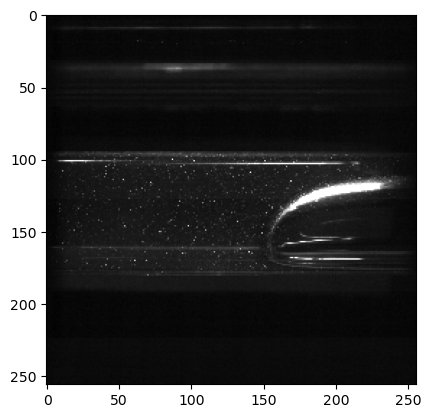

In [17]:
plt.imshow(image_dataset[3,:,:,0], cmap='gray')
plt.show()

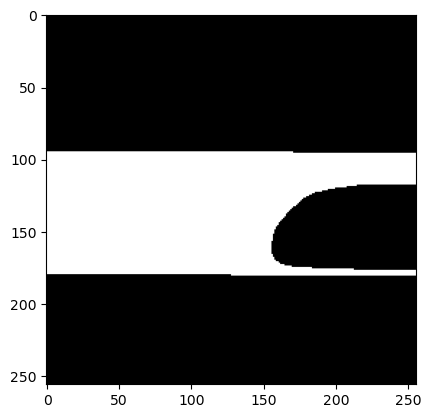

In [19]:
plt.imshow(mask_dataset[3,:,:,0], cmap='gray')
plt.show()

## Model instantiation

In [21]:
Unet =tf.keras.models.load_model("U-Net2pf_8.hdf5",
                                 custom_objects={'dice_coefficient': dice_coefficient,
                                                'seg_dice_loss': seg_dice_loss})

/Users/walissonpinto/anaconda3/lib/python3.11/site-packages/keras/initializers/initializers.py:120: UserWarning: The initializer HeNormal is unseeded and being called multiple times, which will return identical values each time (even if the initializer is unseeded). Please update your code to provide a seed to the initializer, or avoid using the same initalizer instance more than once.
  warnings.warn(


## Model prediction

In [24]:
#IoU: Intersection Over Union
y_pred=Unet.predict(image_dataset)
y_pred_thresholded = y_pred > 0.5

2026-01-16 23:30:23.152962: W tensorflow/tsl/platform/profile_utils/cpu_utils.cc:128] Failed to get CPU frequency: 0 Hz


1/1 [==============================] - 5s 5s/step


## Showing the results

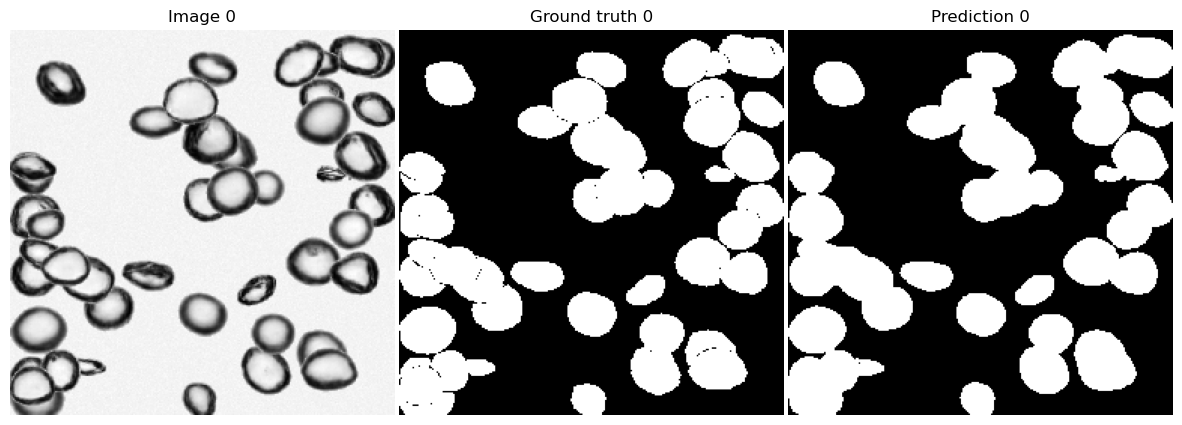

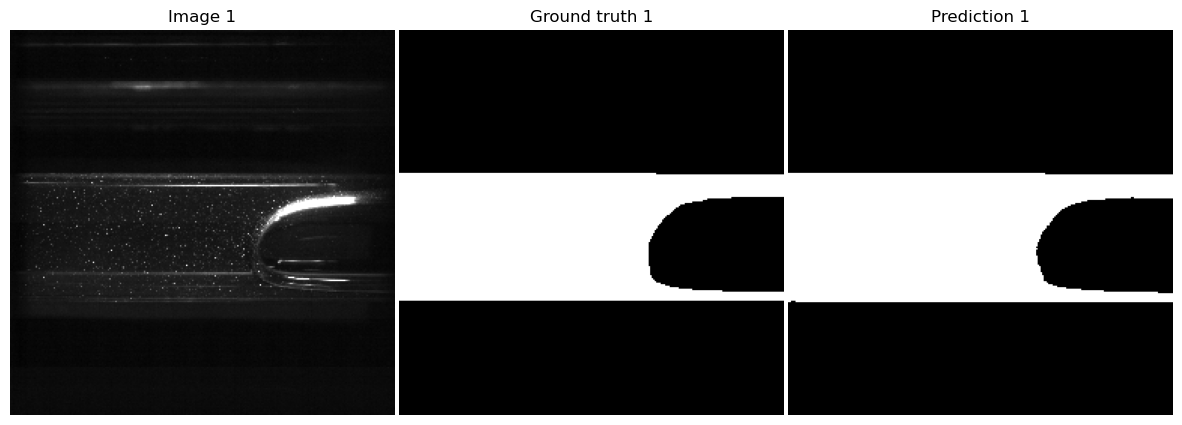

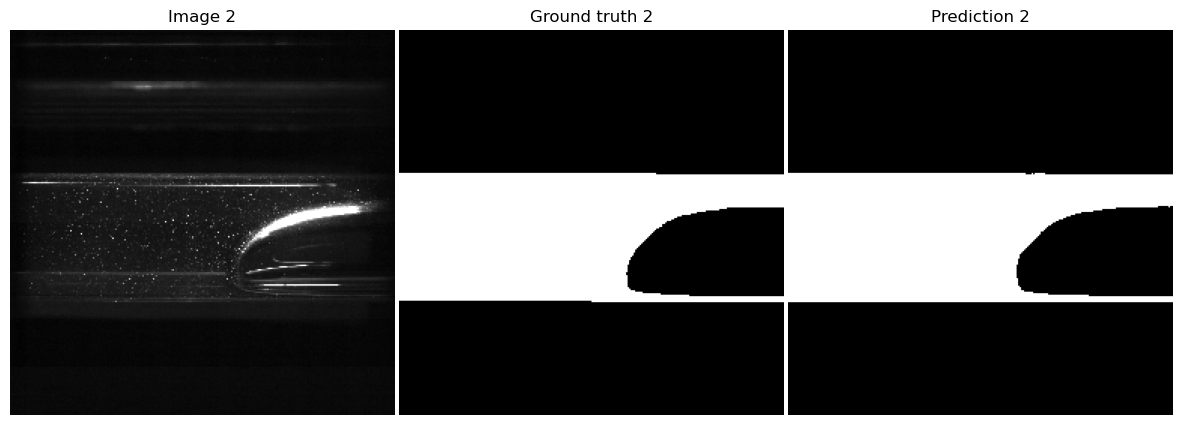

In [26]:
sp = 3 # Number of samples displayed


for i in range(0,sp,1):
    
    f = plt.subplots(1, 3, figsize=(15, 15))
    
    ax1 = plt.subplot(131)
    ax1.set_title('Image '+str(i))
    ax1.imshow(image_dataset[i,:,:,0],cmap='gray')
    ax1.axis('off')

    ax2 = plt.subplot(132)
    ax2.set_title('Ground truth '+str(i))
    ax2.imshow(mask_dataset[i,:,:,0],cmap='gray')
    ax2.axis('off')
    
    ax3 = plt.subplot(133)
    ax3.set_title('Prediction '+str(i))
    ax3.imshow(y_pred_thresholded[i,:,:,0],cmap='gray')
    ax3.axis('off')

    plt.subplots_adjust(wspace=0.01)
    plt.show()